In [1]:
import sys
sys.path.insert(0, "../..")           # or an absolute path
from process_ela_instance_stats import load_repro, repro_to_dataframe
from ela_cv_features import CV_SAFE
from repro_analysis import prepare
import repro_plots as rp
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
BASE = Path("/Users/leekaijen/t7ssd/featELA/")
SOURCES = {d: BASE / f"dim{d}featELA" / "ela_stats.pkl" for d in (2, 5, 10)}

In [3]:
df  = pd.concat([repro_to_dataframe(load_repro(p)) for p in SOURCES.values()],
                ignore_index=True)
tab = prepare(df)          # prints regression alpha, ratio-implied alpha, SD ratios

pf, al, rt, br = tab["per_func"], tab["alpha"], tab["ratios"], tab["budget_ratio"]
BIG, REPS = df["size"].max(), [1, 5, 8, 12, 16, 21, 23]

dropped 403,200 rows for 5 excluded feature(s): disp.diff_mean_02, disp.diff_median_02, disp.ratio_mean_02, disp.ratio_median_02, ela_meta.quad_simple.cond
per-function rows : 75,456  (45 features x 24 functions x 6 strategies)
alpha fits        : 18,162  (median r2 = 0.996)
median alpha by strategy (regression):
    sobol            0.627
    lhs_random_cd    0.556
    ilhs             0.544
    uniform          0.518
    lhs              0.517
    cma_random       0.020
implied alpha from SD(25) / SD(100) ratio [no regression]:
    cma_random       ratio=1.04  alpha=0.031
    ilhs             ratio=2.16  alpha=0.556
    lhs              ratio=2.05  alpha=0.519
    lhs_random_cd    ratio=2.20  alpha=0.569
    sobol            ratio=2.44  alpha=0.643
    uniform          ratio=2.06  alpha=0.521
SD ratio vs uniform (median, pooled):
    cma_random       2.309x
    ilhs             0.886x
    lhs              0.961x
    lhs_random_cd    0.779x
    sobol            0.784x
    uniform     

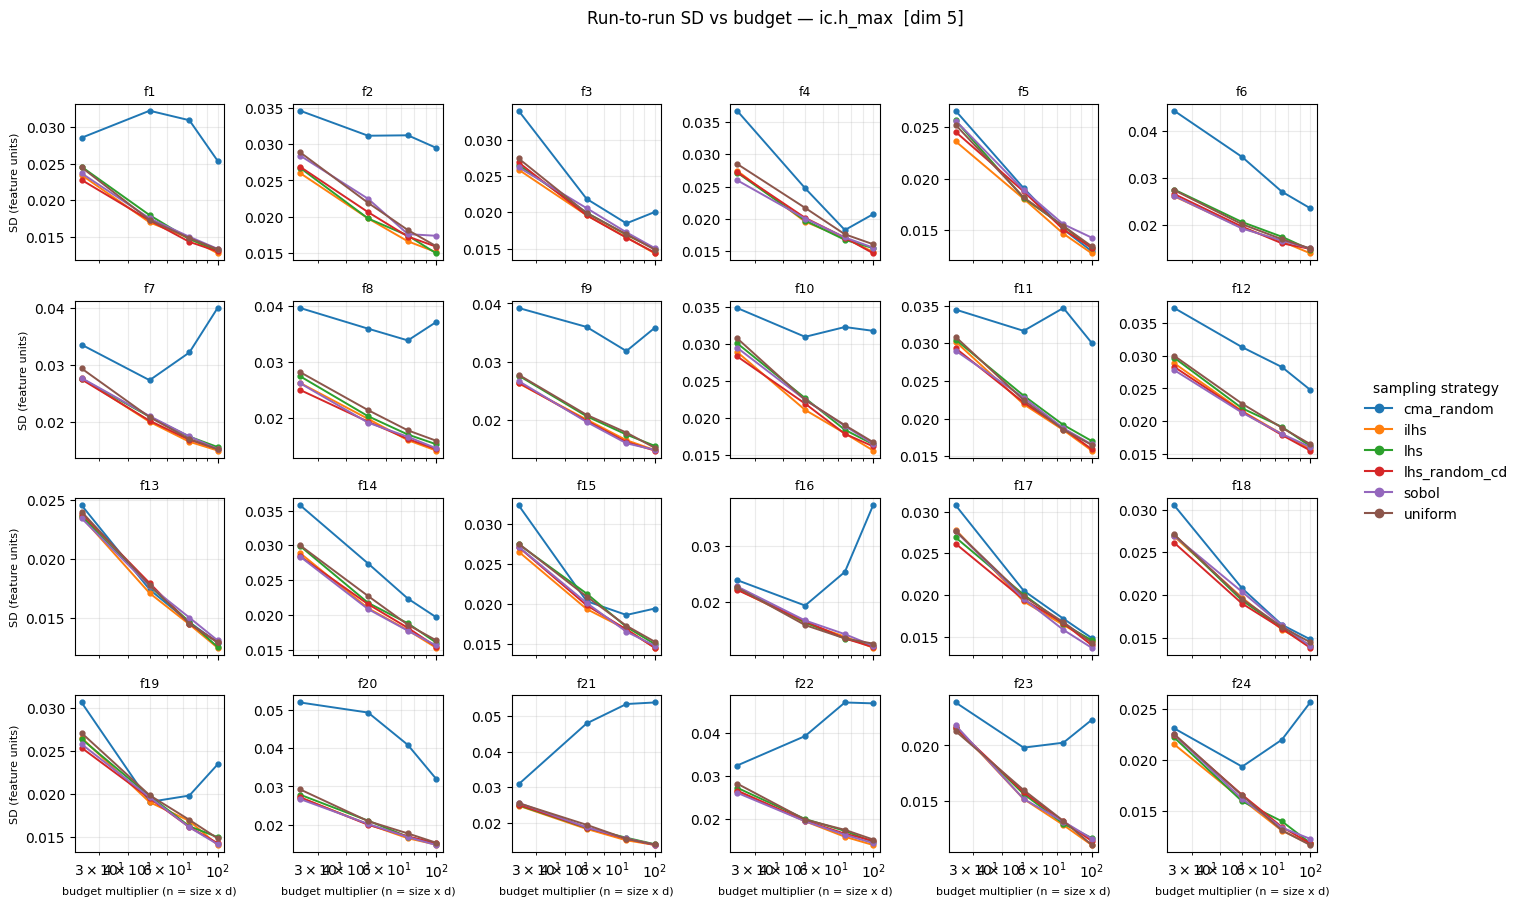

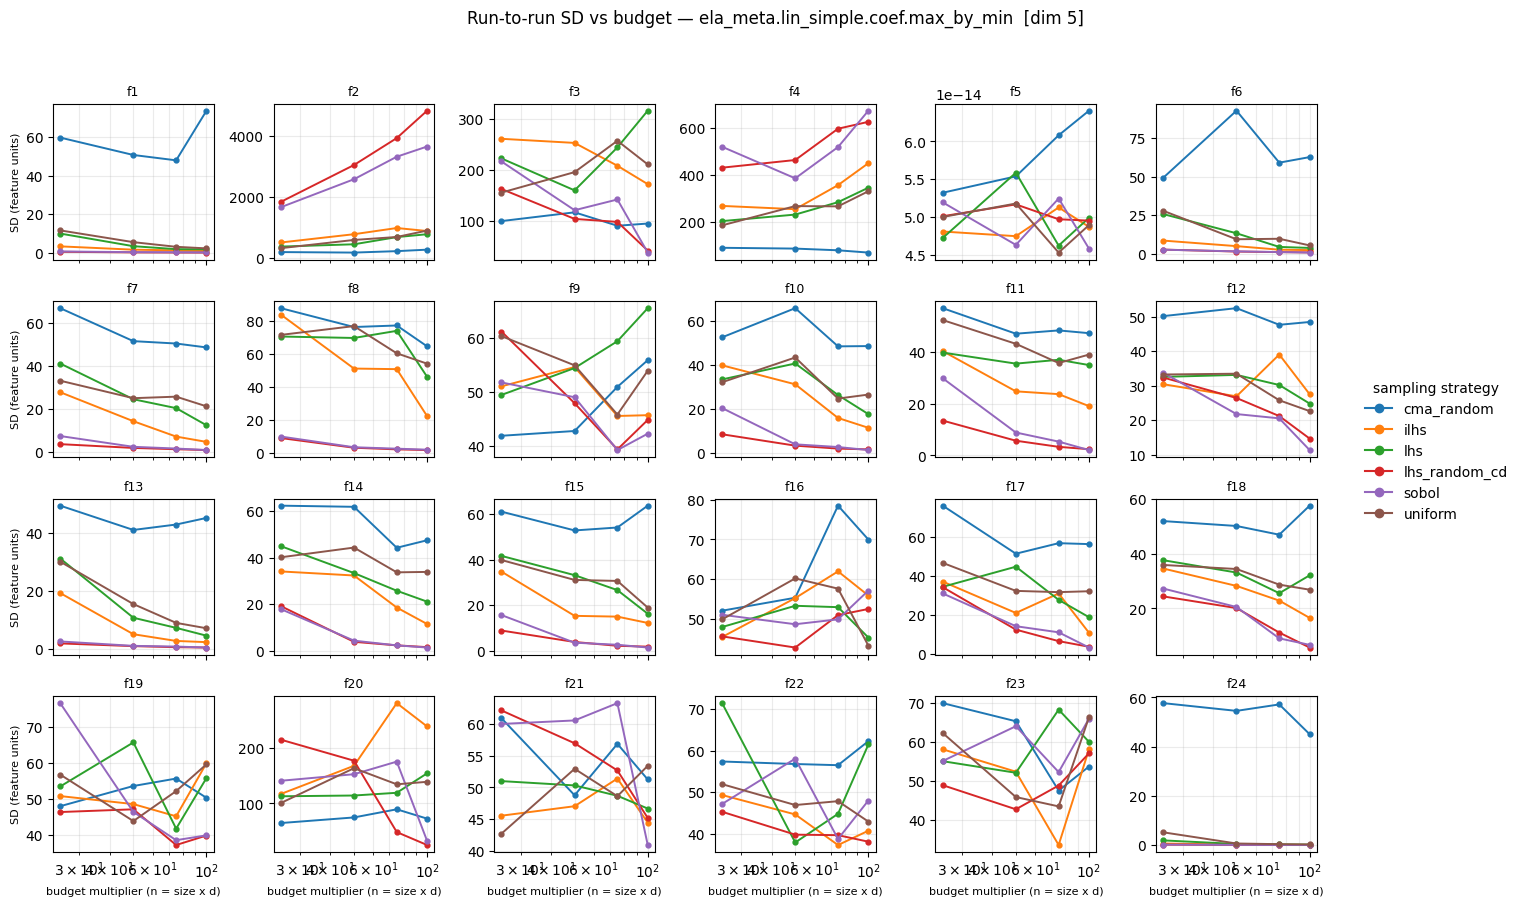

In [4]:
_ = rp.plot_sd_vs_budget(pf, dimension=5, feature="ic.h_max", logy=False)
_ = rp.plot_sd_vs_budget(pf, 5, "ela_meta.lin_simple.coef.max_by_min",logy=False)   # heavy-tailed

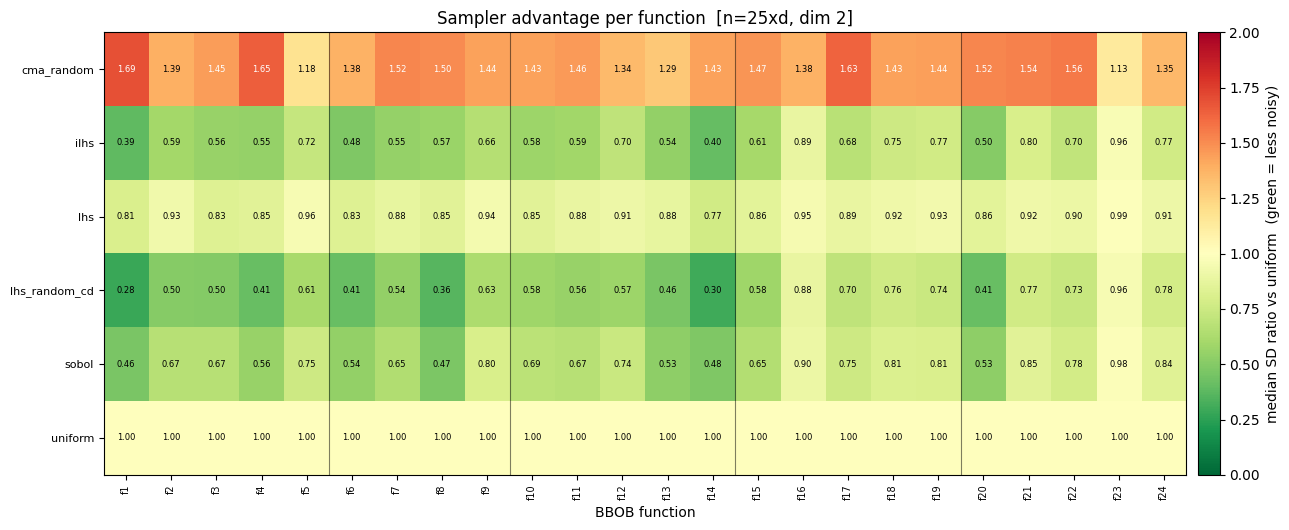

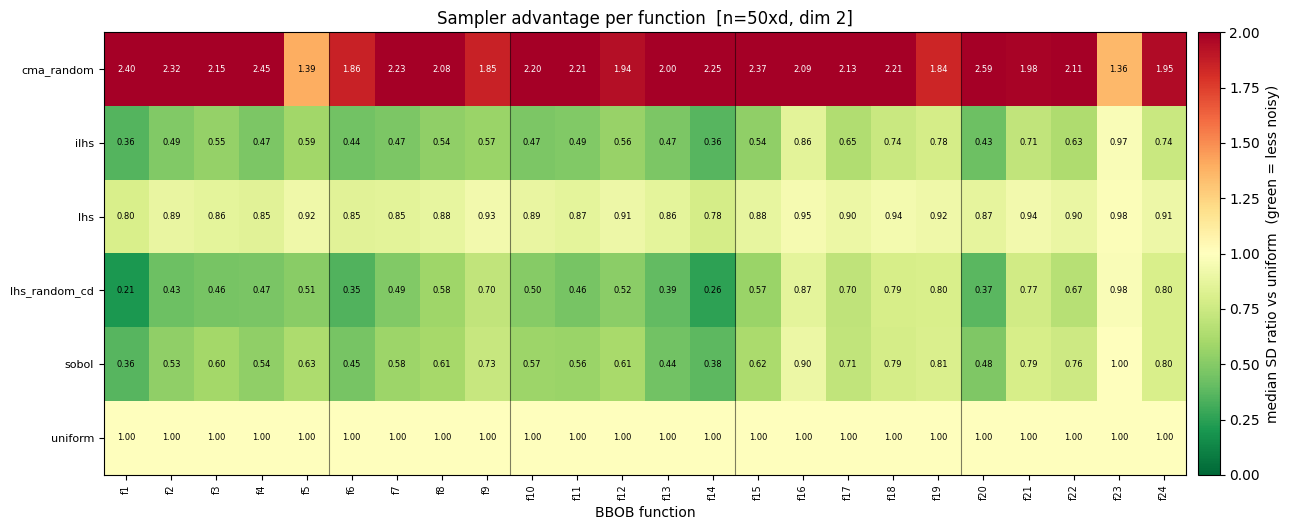

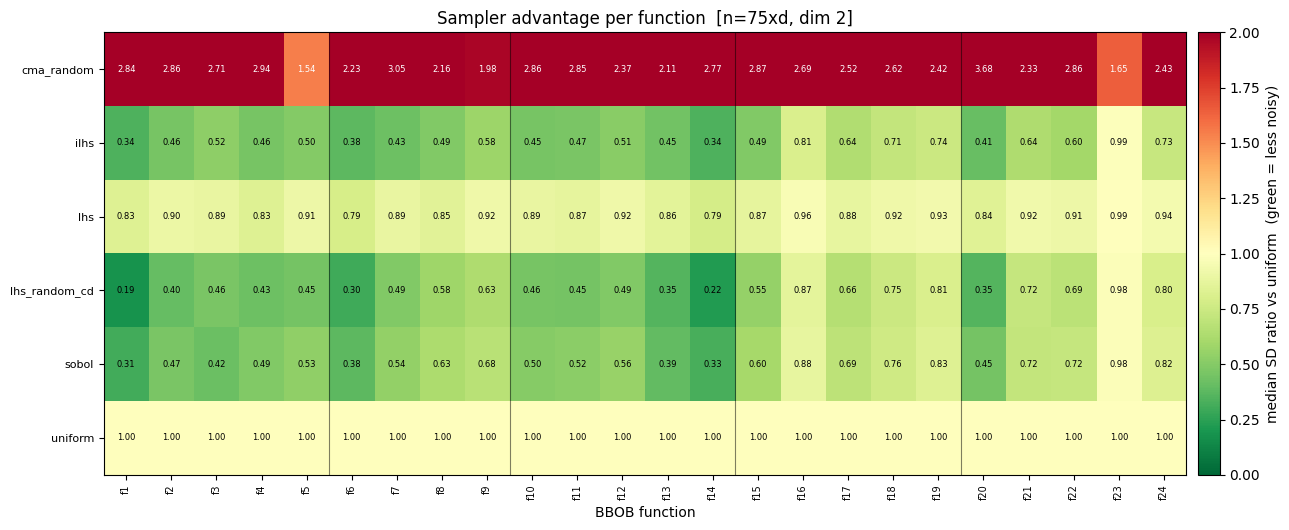

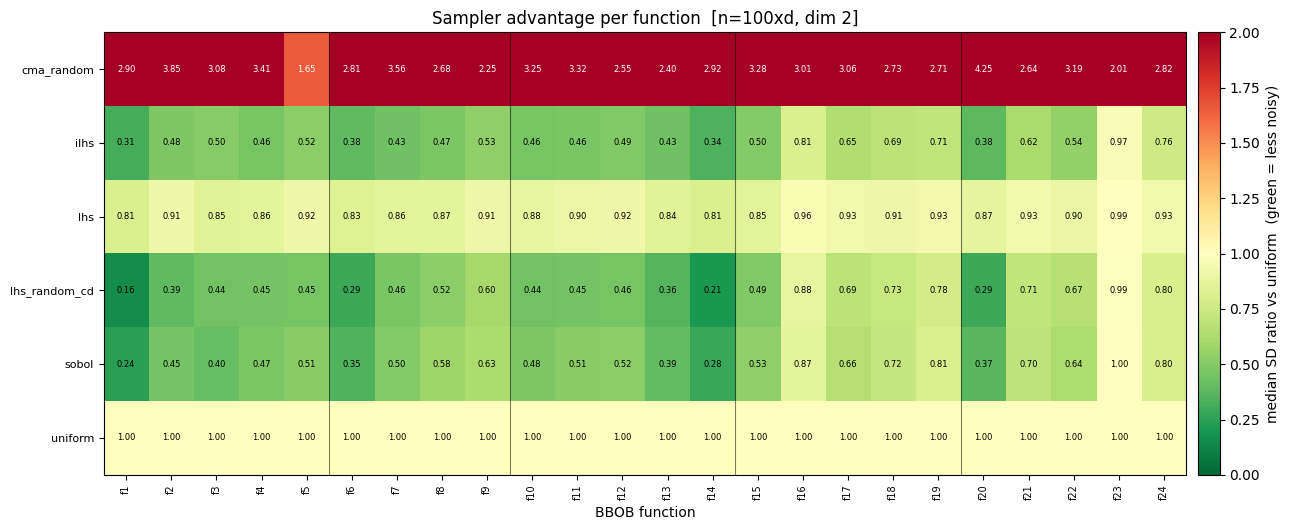

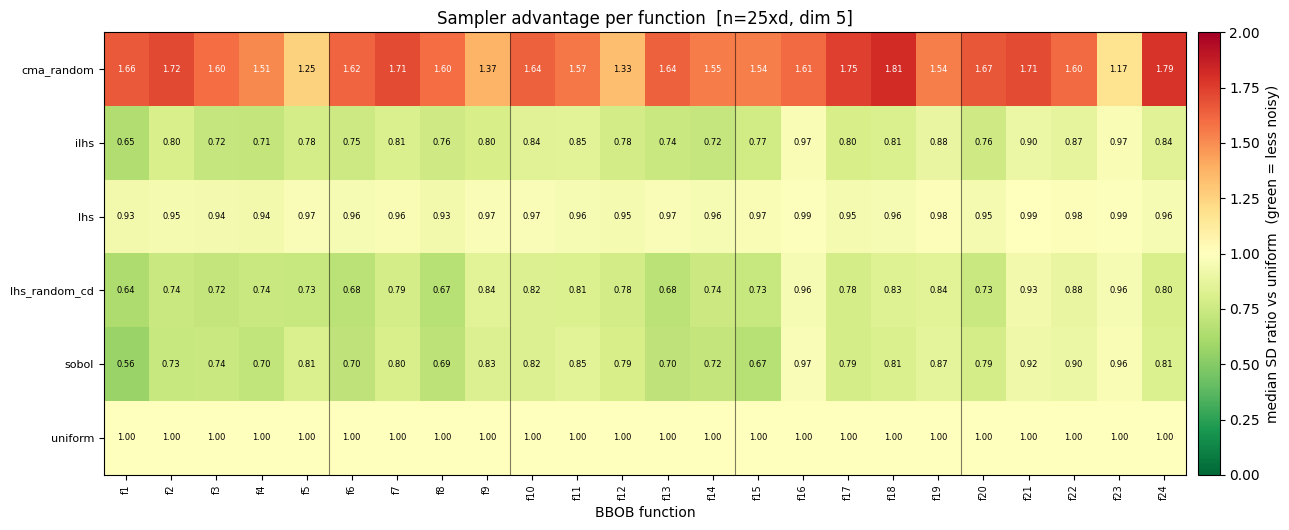

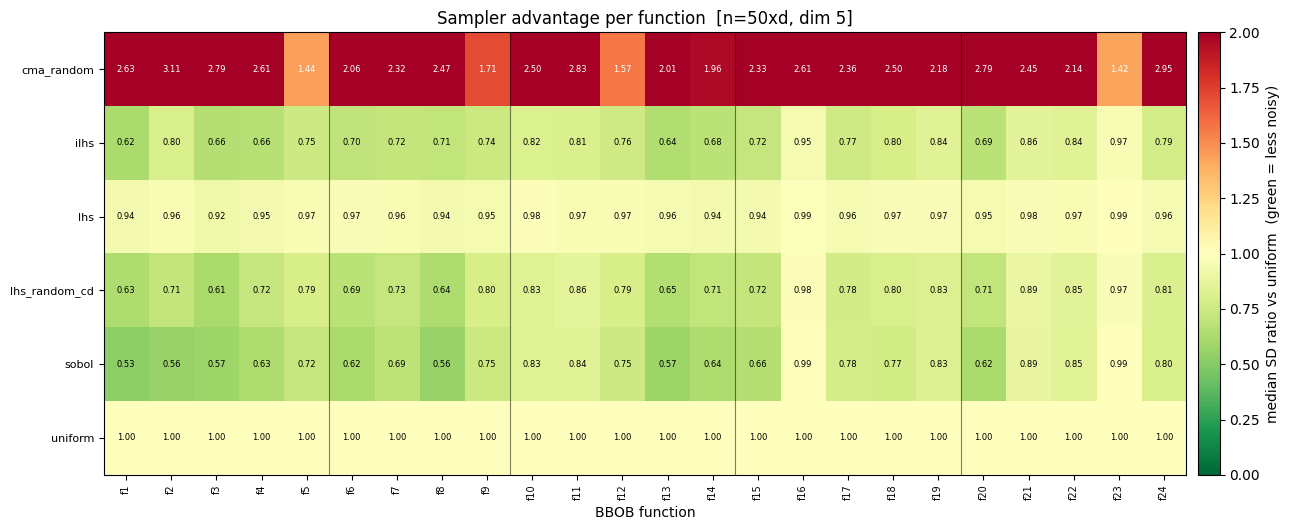

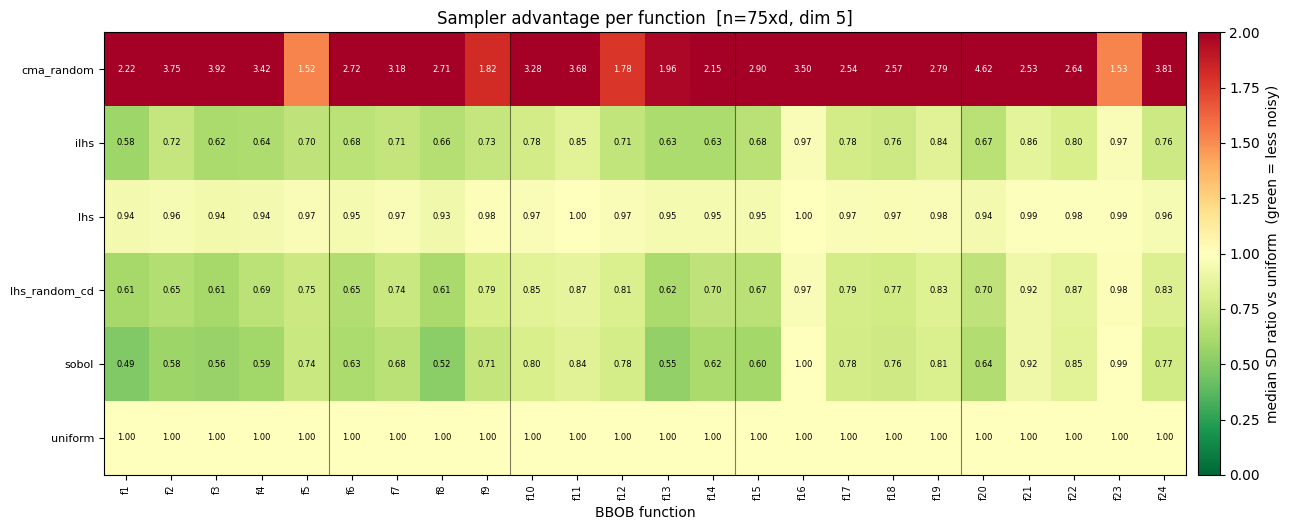

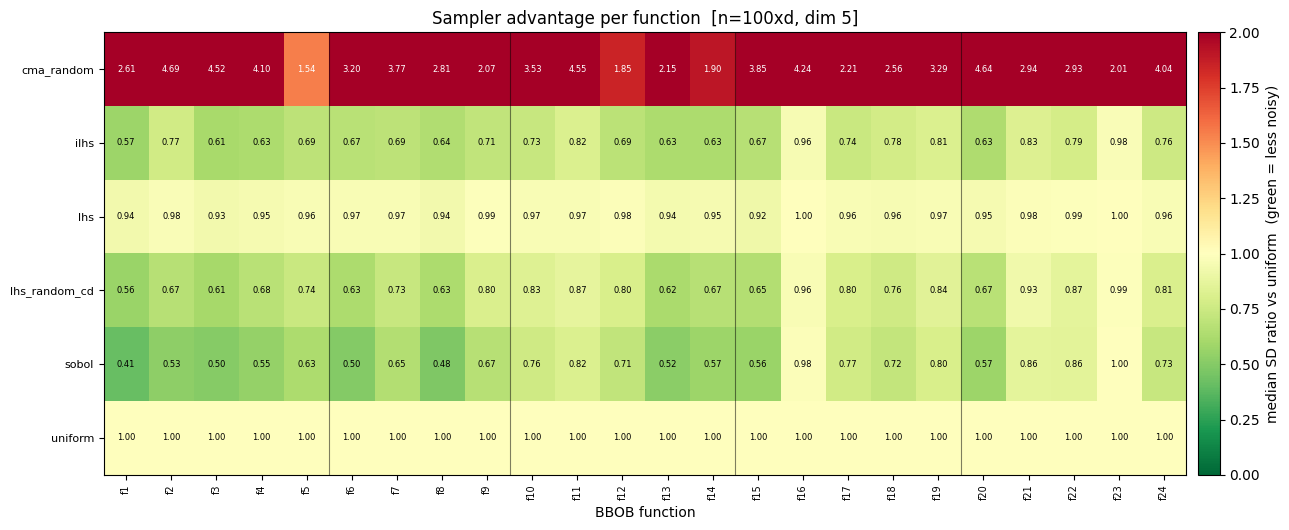

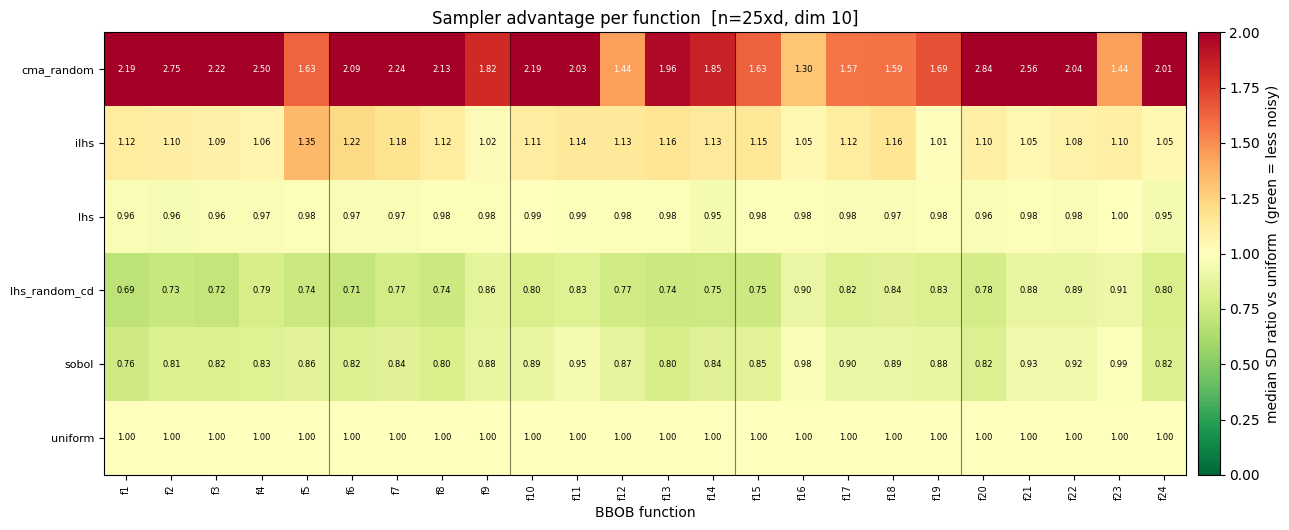

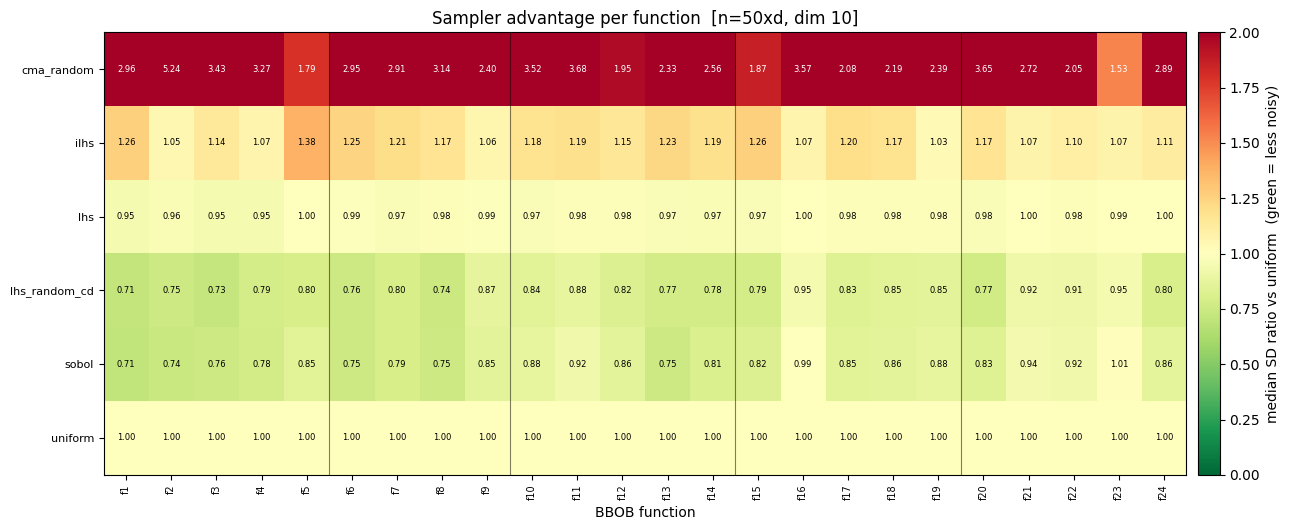

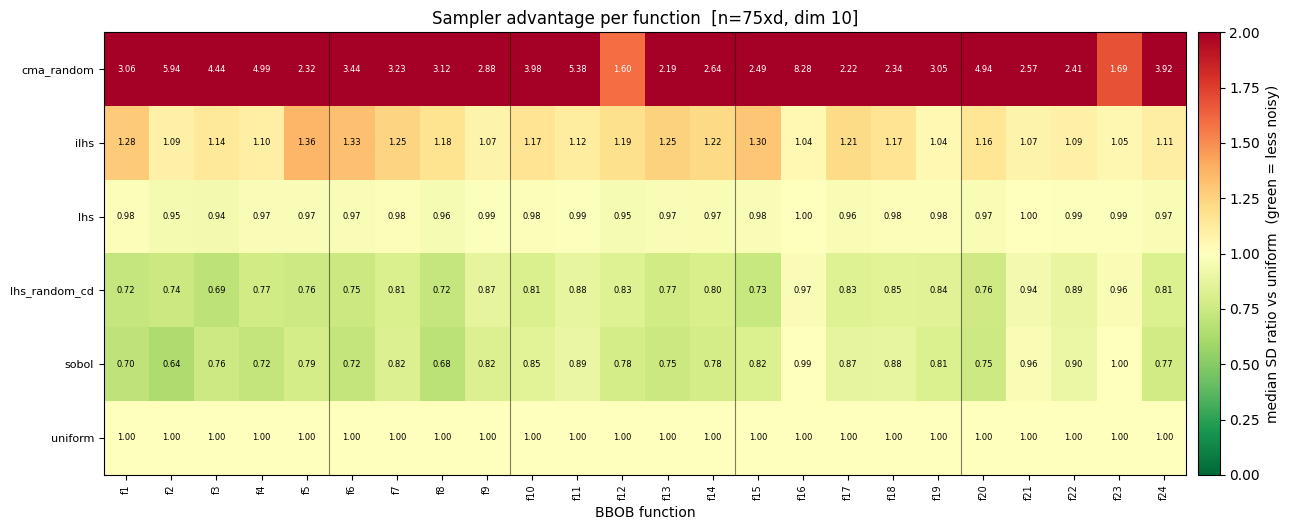

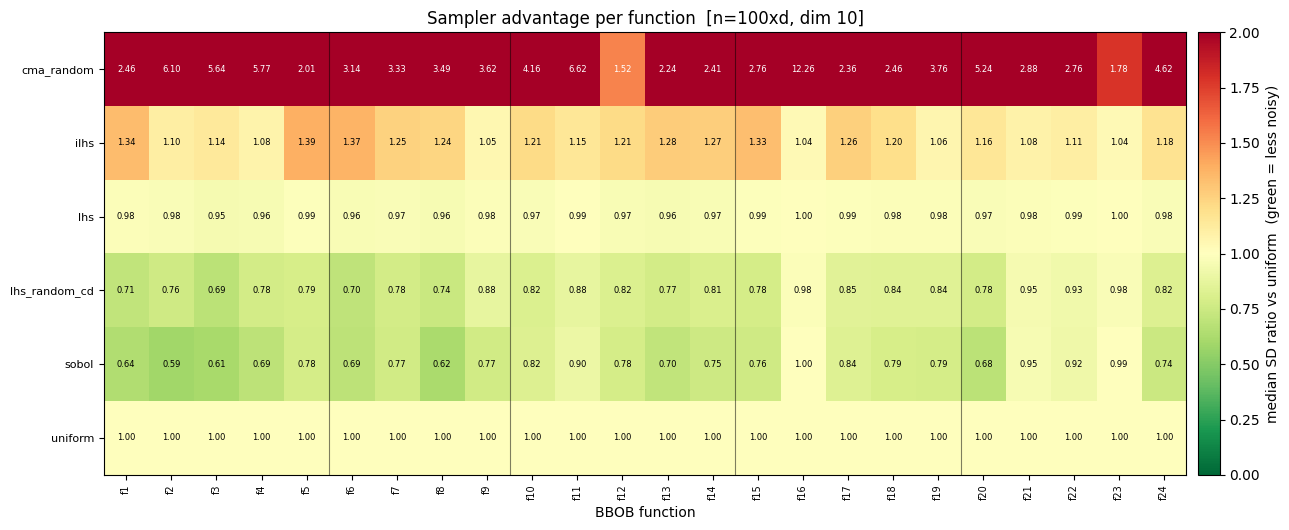

In [5]:
# _ = rp.boxplot_sampler_ratio(rt, dimension=5, size=BIG, width=15)   # R1
# _ = rp.boxplot_budget_ratio(br, dimension=5, width=15)              # R2 — alpha, no regression
_ = rp.heatmap_ratio_by_function(rt, 2, 25)              # R3
_ = rp.heatmap_ratio_by_function(rt, 2, 50)              # R3
_ = rp.heatmap_ratio_by_function(rt, 2, 75)              # R3
_ = rp.heatmap_ratio_by_function(rt, 2, 100)              # R3
_ = rp.heatmap_ratio_by_function(rt, 5, 25)              # R3
_ = rp.heatmap_ratio_by_function(rt, 5, 50)              # R3
_ = rp.heatmap_ratio_by_function(rt, 5, 75)              # R3
_ = rp.heatmap_ratio_by_function(rt, 5, 100)              # R3
_ = rp.heatmap_ratio_by_function(rt, 10, 25)              # R3
_ = rp.heatmap_ratio_by_function(rt, 10, 50)              # R3
_ = rp.heatmap_ratio_by_function(rt, 10, 75)              # R3
_ = rp.heatmap_ratio_by_function(rt, 10, 100)              # R3


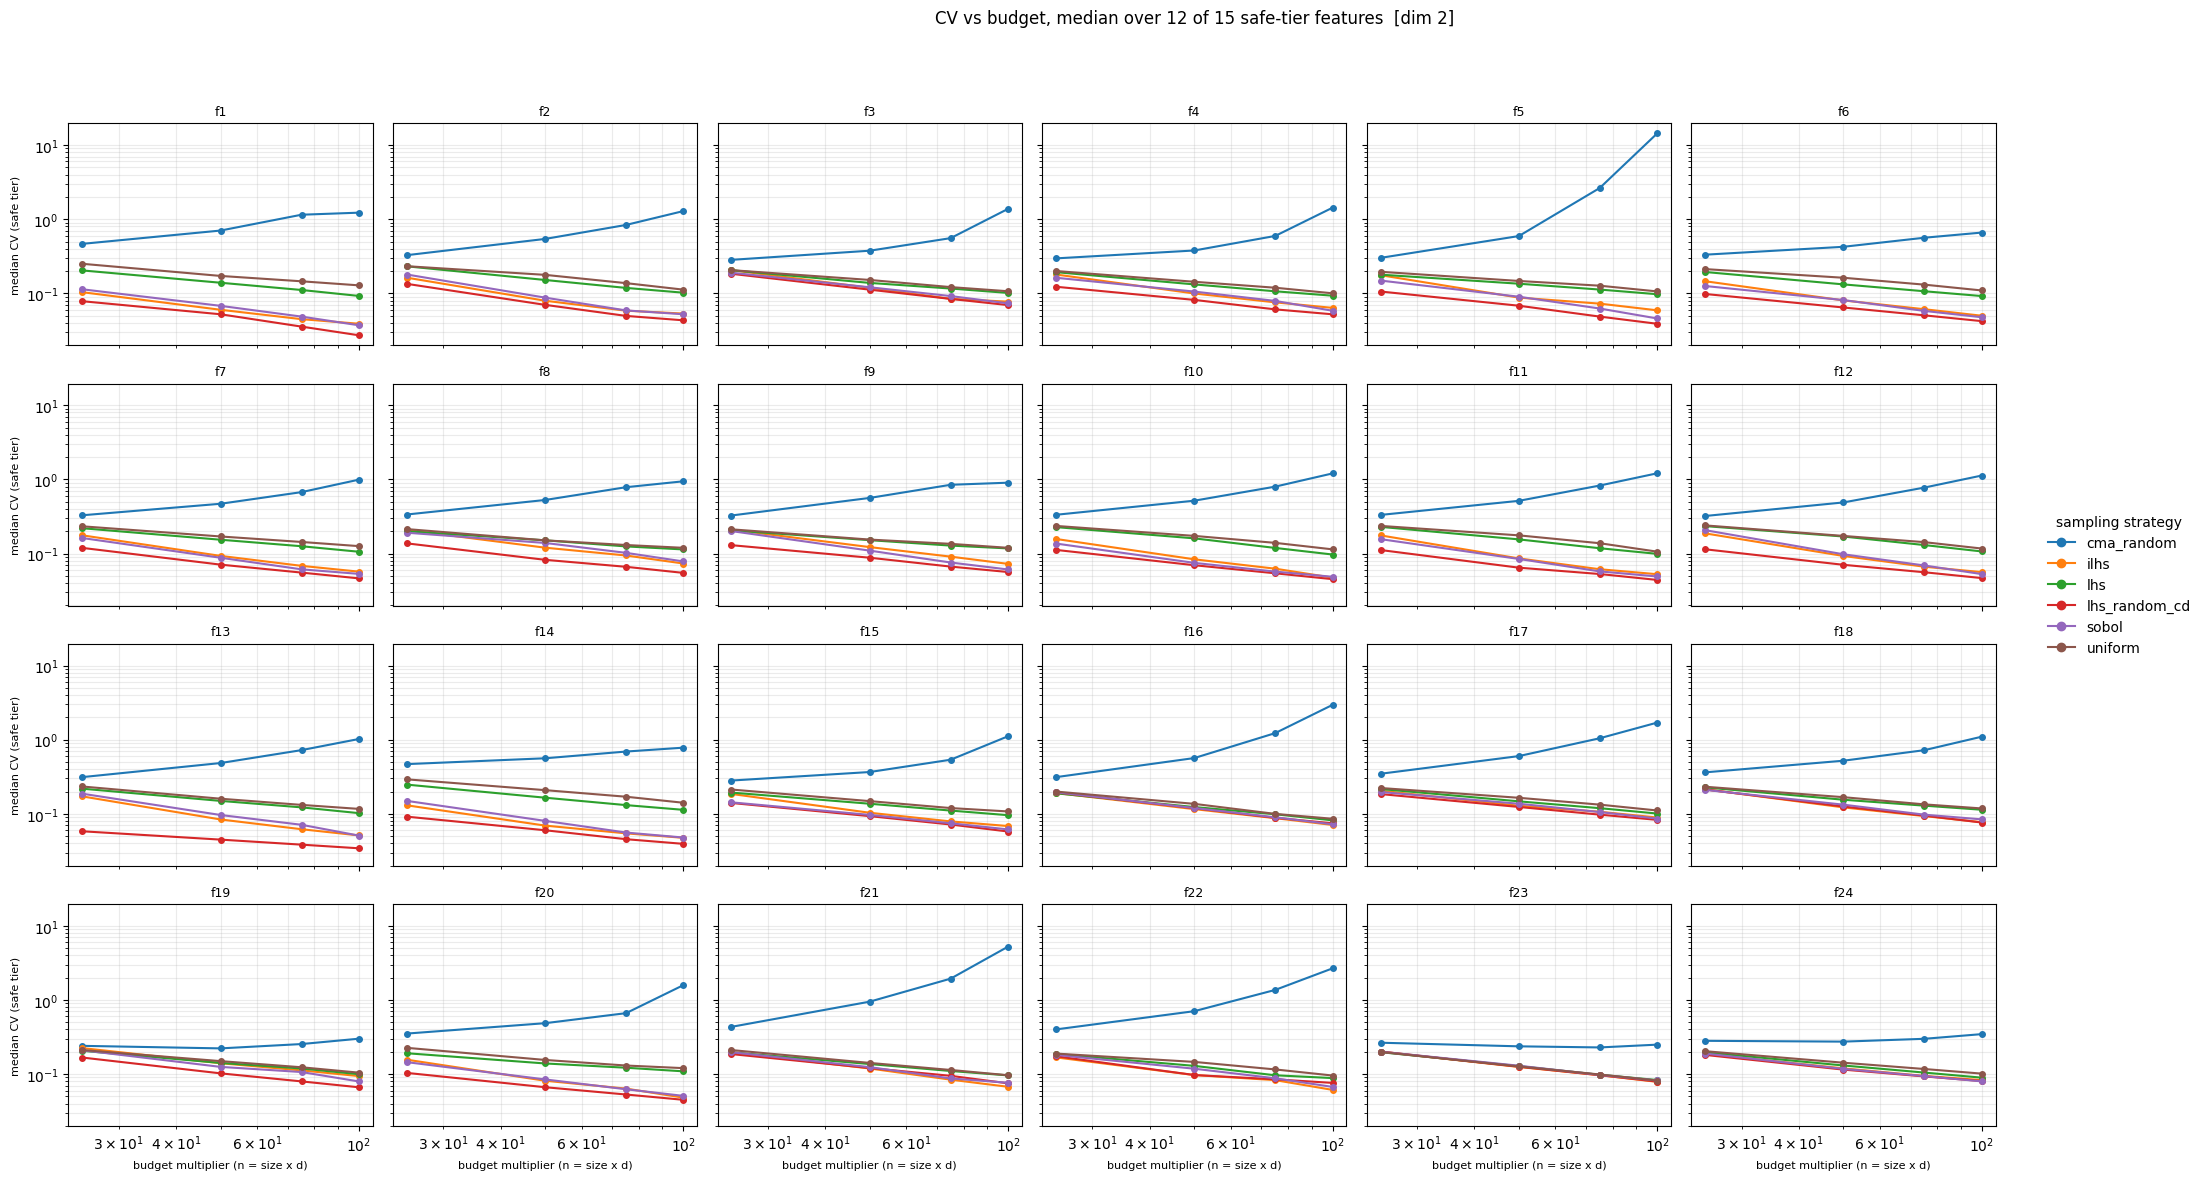

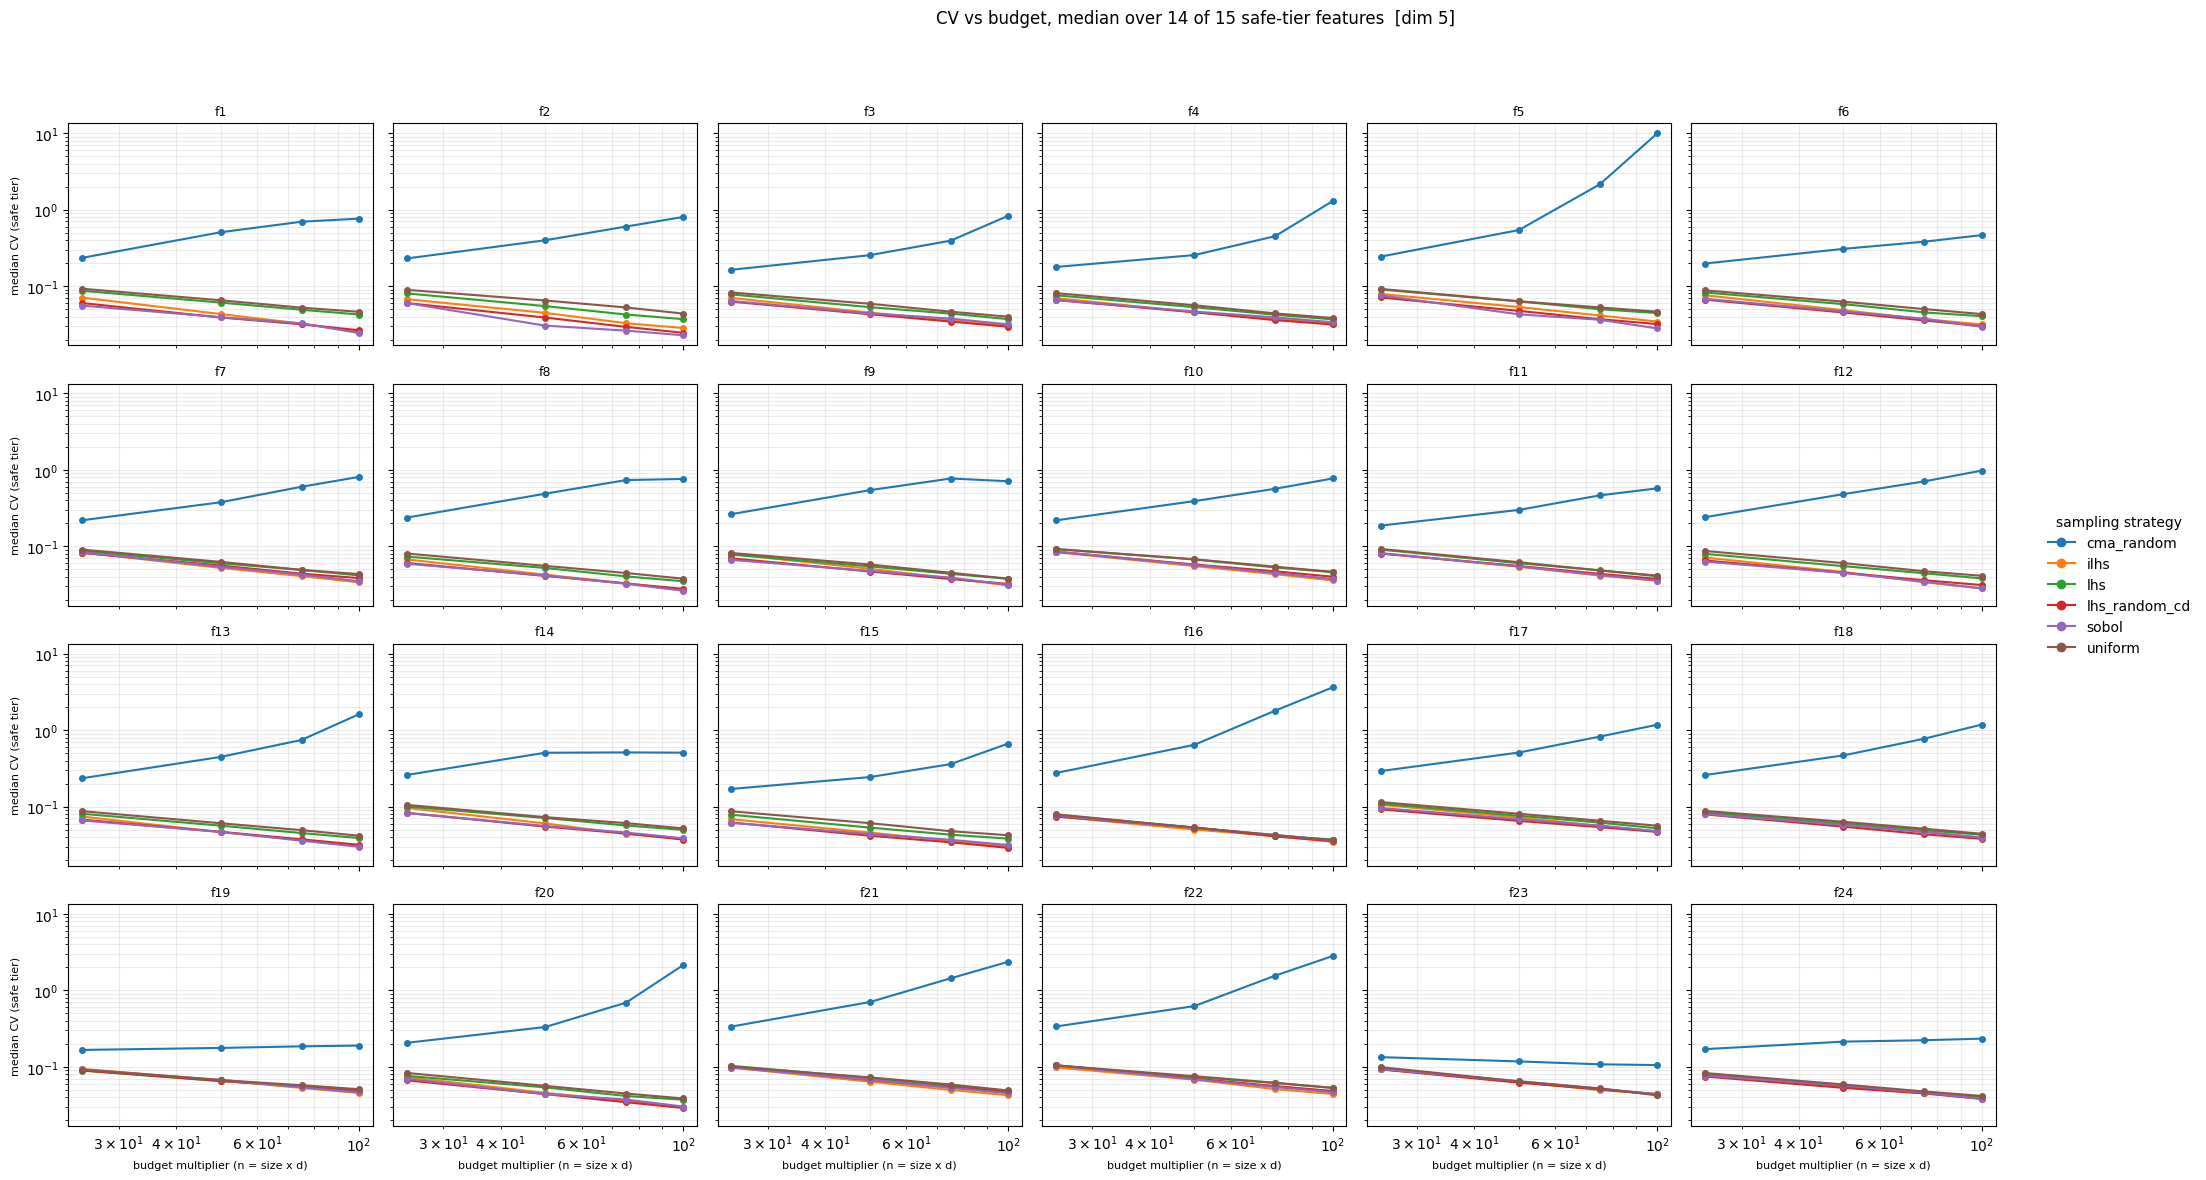

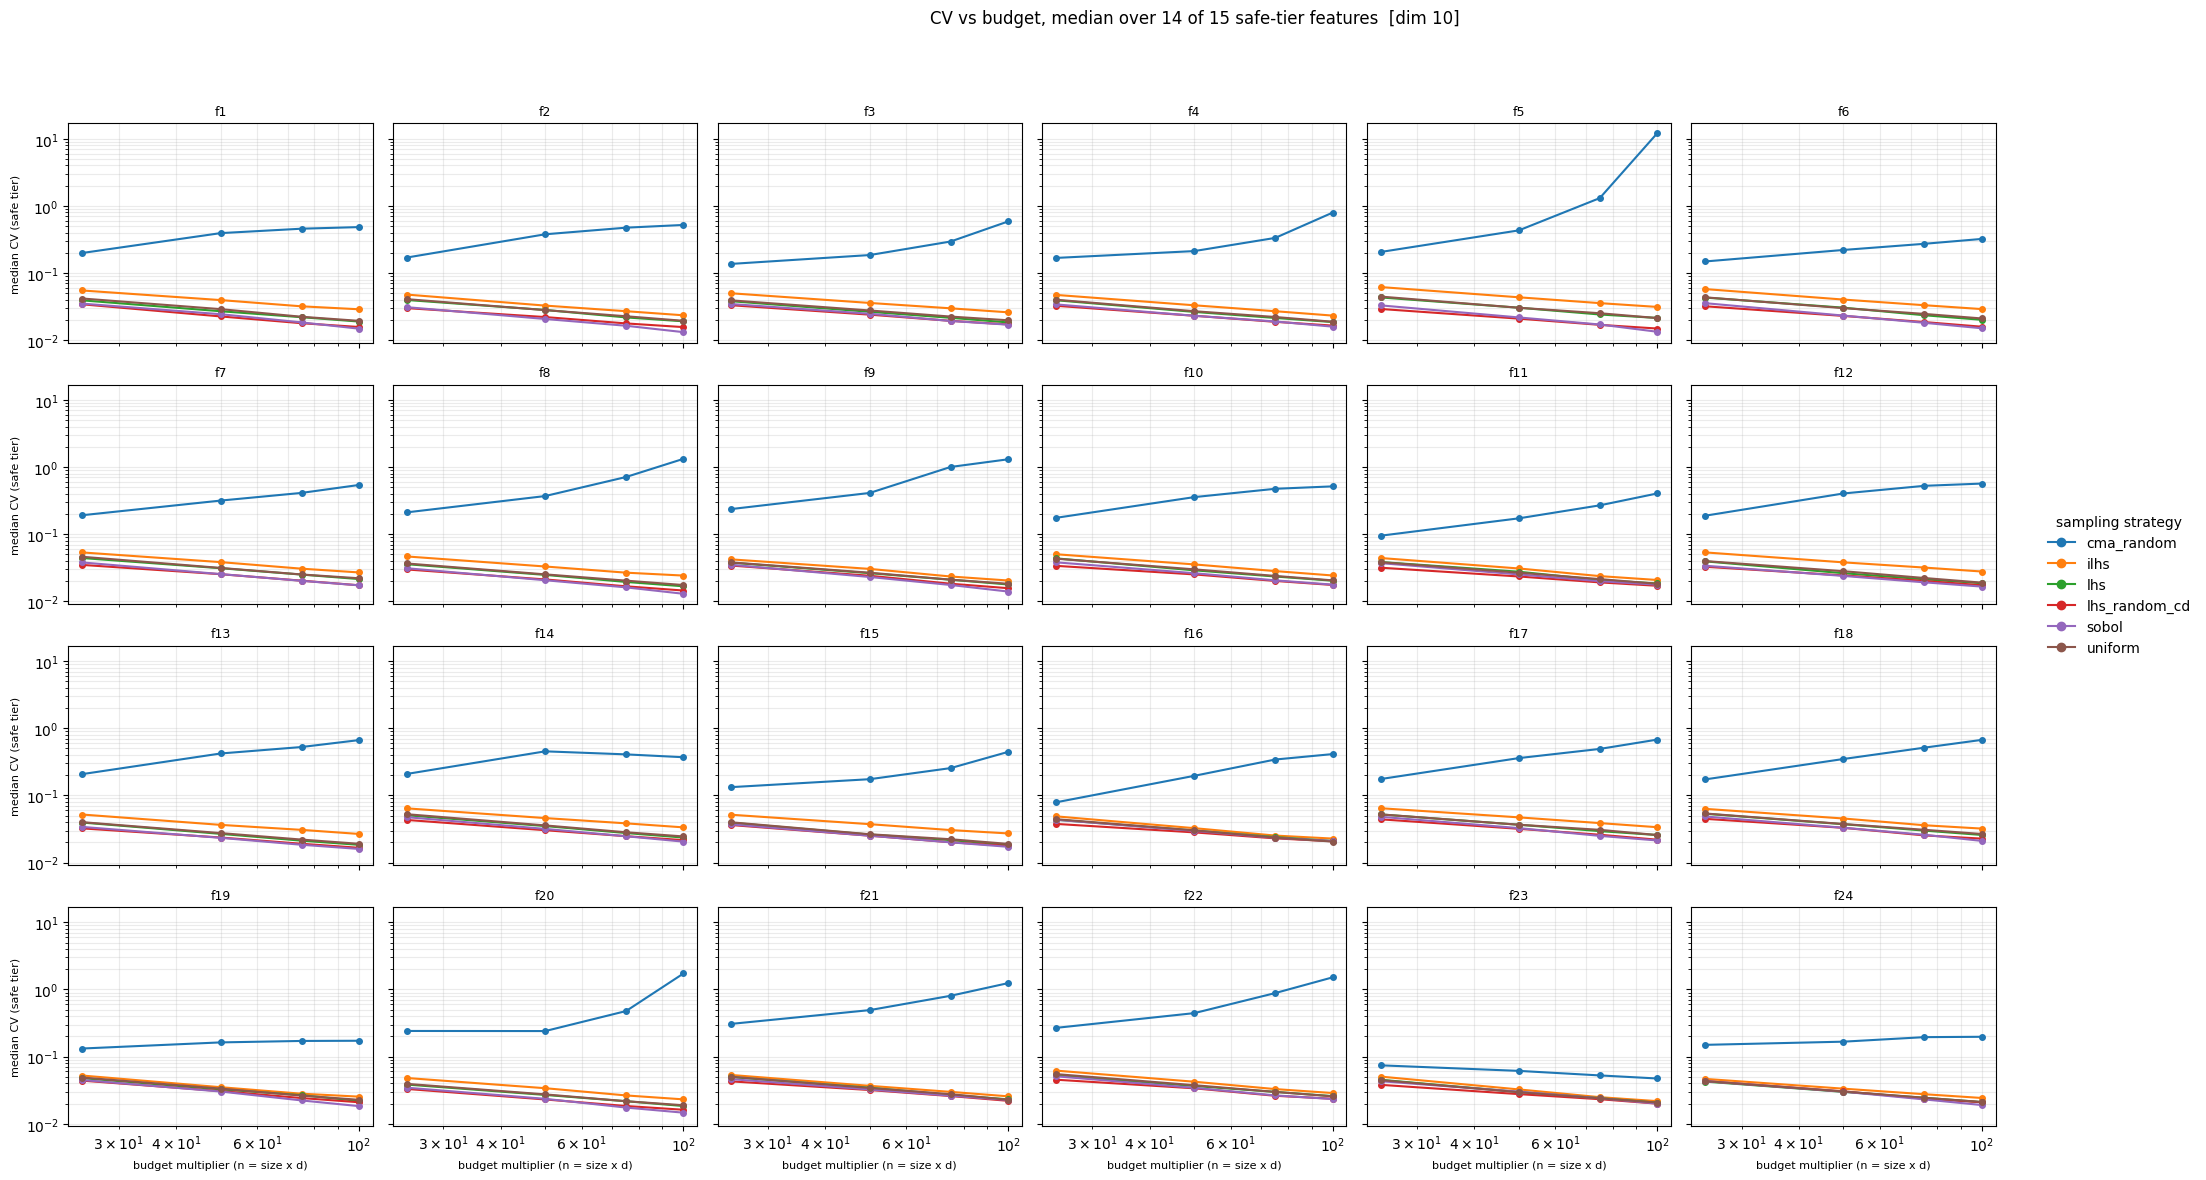

In [6]:
_ = rp.plot_cv_vs_budget(pf, 2, list(range(1, 25)), CV_SAFE, ncols=6,
                         width_per=4, height_per=3)
_ = rp.plot_cv_vs_budget(pf, 5, list(range(1, 25)), CV_SAFE, ncols=6,
                         width_per=4, height_per=3)
_ = rp.plot_cv_vs_budget(pf, 10, list(range(1, 25)), CV_SAFE, ncols=6,
                         width_per=4, height_per=3)

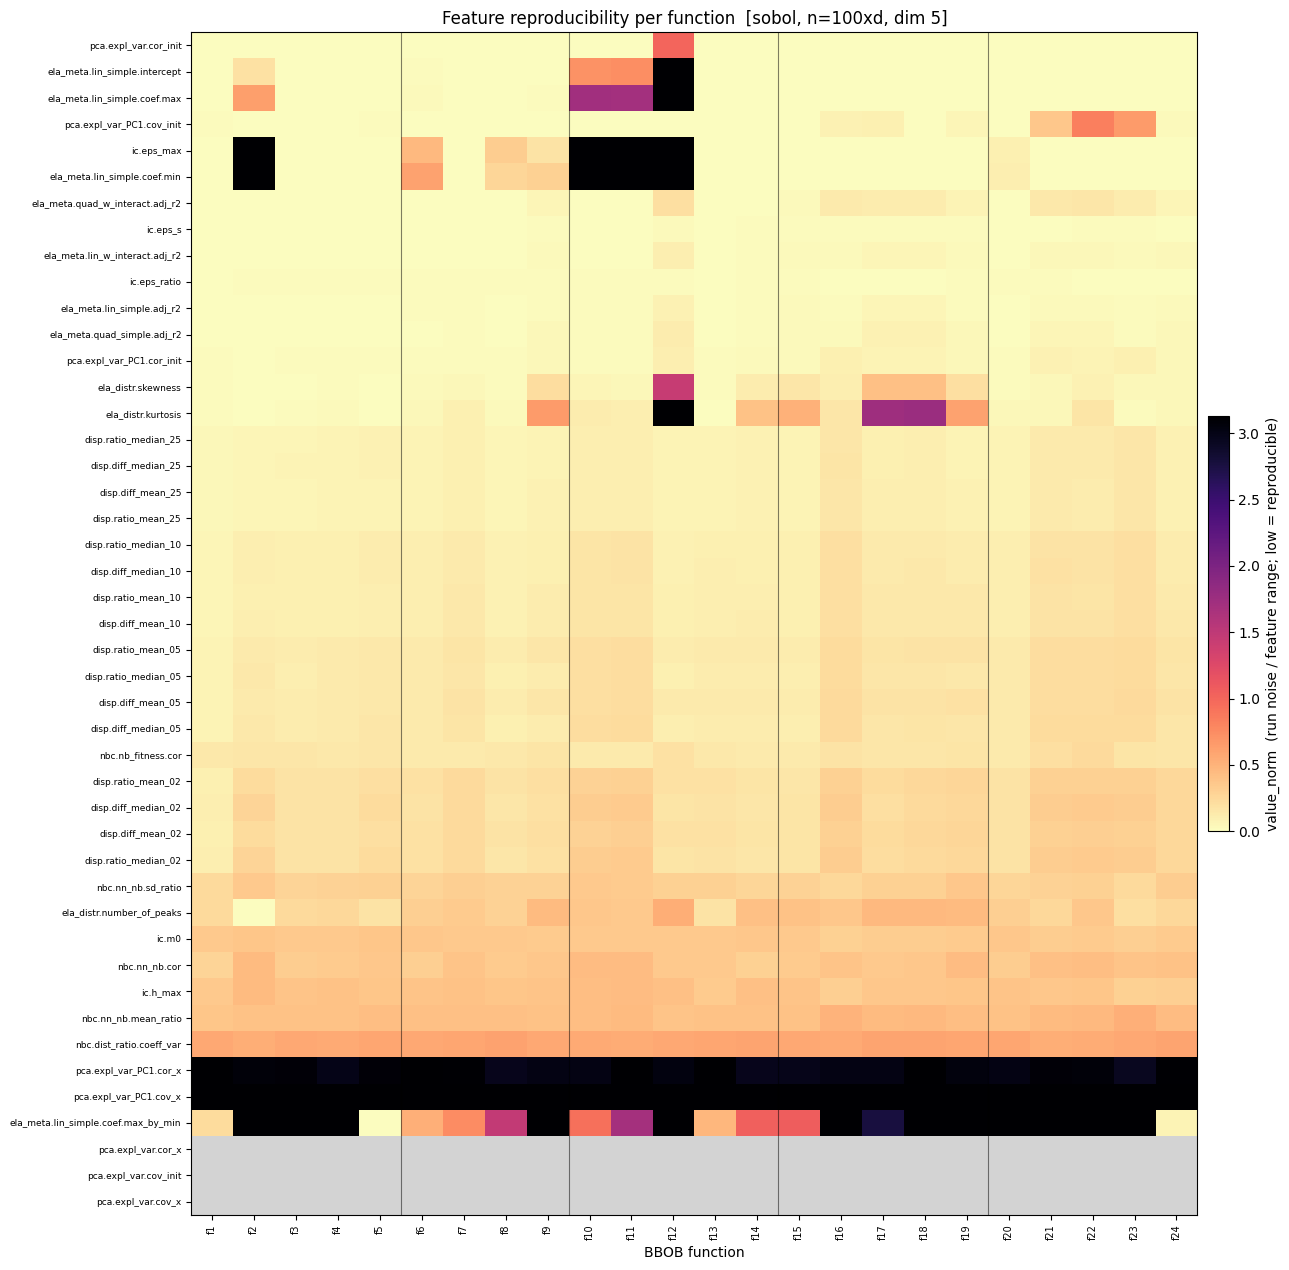

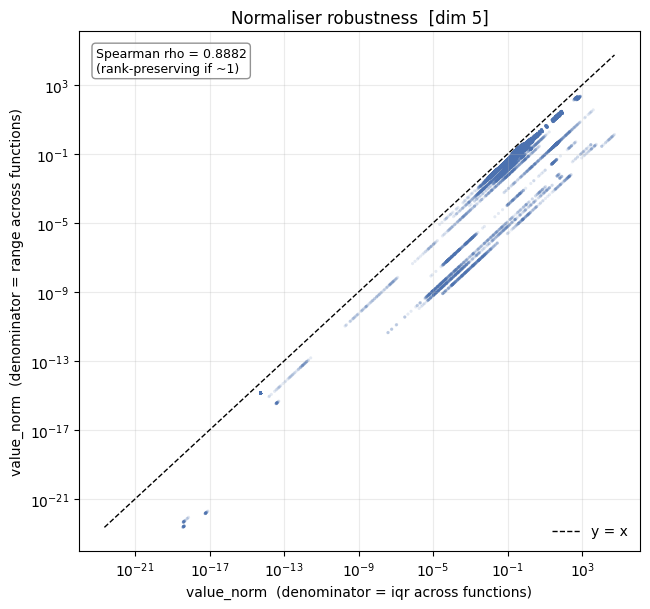

In [7]:
_ = rp.heatmap_feature_function(pf, 5, "sobol", BIG)      # V1
_ = rp.scatter_normaliser_robustness(pf, 5)   #V2

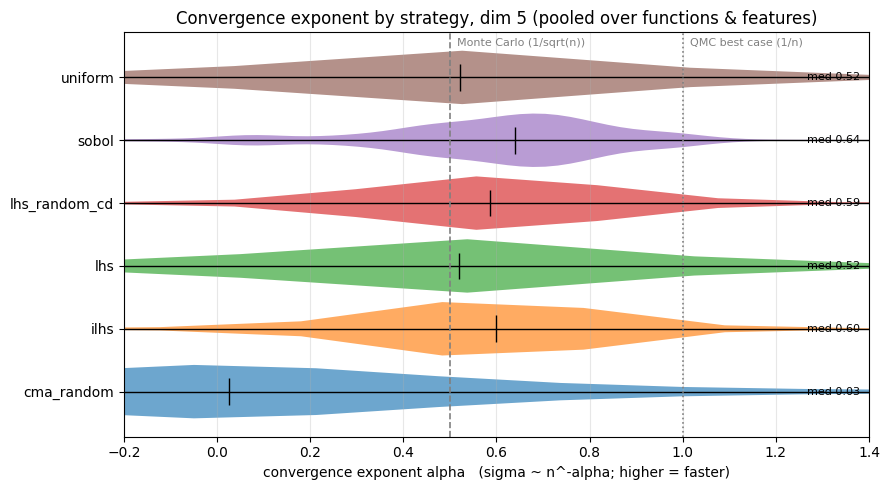

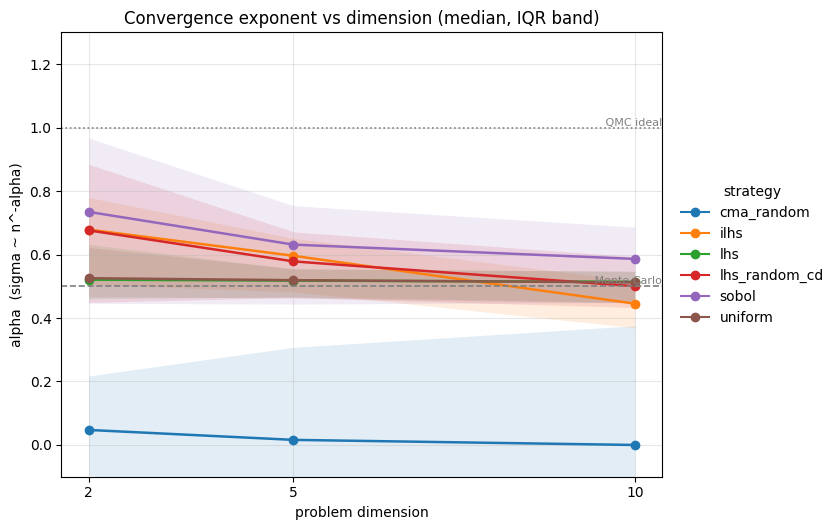

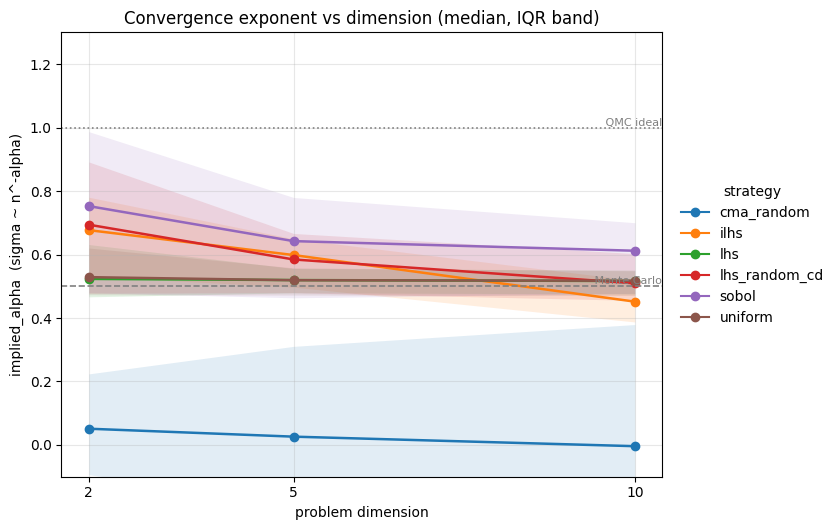

In [8]:
_ = rp.alpha_distribution(al, dimension=5)                # A1
_ = rp.plot_alpha_vs_dimension(al)                        # A4 (regression)
_ = rp.plot_alpha_vs_dimension(br, use="implied_alpha")   # A4 (ratio — no fit)

In [9]:
(df.assign(incomplete=df.n_finite < 30)
   .groupby(["dimension", "feature"])["incomplete"].mean()
   .unstack(0).sort_values(2, ascending=False).head(15))

dimension,2,5,10
feature,,,
disp.diff_mean_02,0.250000,0.000000,0.000000
disp.diff_median_02,0.250000,0.000000,0.000000
disp.ratio_mean_02,0.250000,0.000000,0.000000
disp.ratio_median_02,0.250000,0.000000,0.000000
ela_meta.quad_simple.cond,0.041667,0.041319,0.029757
ic.eps_ratio,0.000191,0.000000,0.000000
pca.expl_var_PC1.cor_init,0.000000,0.000000,0.000000
ela_meta.quad_w_interact.adj_r2,0.000000,0.000000,0.000000
ic.eps_max,0.000000,0.000000,0.000000


In [10]:
df[df.n_finite < 30].groupby(["dimension","feature"])["n_finite"].describe()

count       mean       std   min   25%  \
dimension feature                                                               
2         disp.diff_mean_02          14400.0   0.119444  0.846122   0.0   0.0   
          disp.diff_median_02        14400.0   0.119444  0.846122   0.0   0.0   
          disp.ratio_mean_02         14400.0   0.119444  0.846122   0.0   0.0   
          disp.ratio_median_02       14400.0   0.119444  0.846122   0.0   0.0   
          ela_meta.quad_simple.cond   2400.0  16.254167  3.369614   6.0  14.0   
          ic.eps_ratio                  11.0  28.818182  0.404520  28.0  29.0   
5         ela_meta.quad_simple.cond   2380.0  25.448319  2.033003  17.0  24.0   
10        ela_meta.quad_simple.cond   1714.0  28.260210  0.936372  24.0  28.0   

                                      50%   75%   max  
dimension feature                                      
2         disp.diff_mean_02           0.0   0.0  15.0  
          disp.diff_median_02         0.0   0.0  15.0  
          disp.ratio_mean_02          0.0   0.0  15.0  
          disp.ratio_median_02        0.0   0.0  15.0  
          ela_meta.quad_simple.cond  16.0  19.0  27.0  
          ic.eps_ratio               29.0  29.0  29.0  
5         ela_meta.quad_simple.cond  26.0  27.0  29.0  
10        ela_meta.quad_simple.cond  29.0  29.0  29.0

In [11]:
(df.assign(bad=df.n_finite < 30)
   .groupby(["dimension","feature"])["bad"].mean()
   .loc[lambda s: s > 0])

dimension  feature                  
2          disp.diff_mean_02            0.250000
           disp.diff_median_02          0.250000
           disp.ratio_mean_02           0.250000
           disp.ratio_median_02         0.250000
           ela_meta.quad_simple.cond    0.041667
           ic.eps_ratio                 0.000191
5          ela_meta.quad_simple.cond    0.041319
10         ela_meta.quad_simple.cond    0.029757
Name: bad, dtype: float64

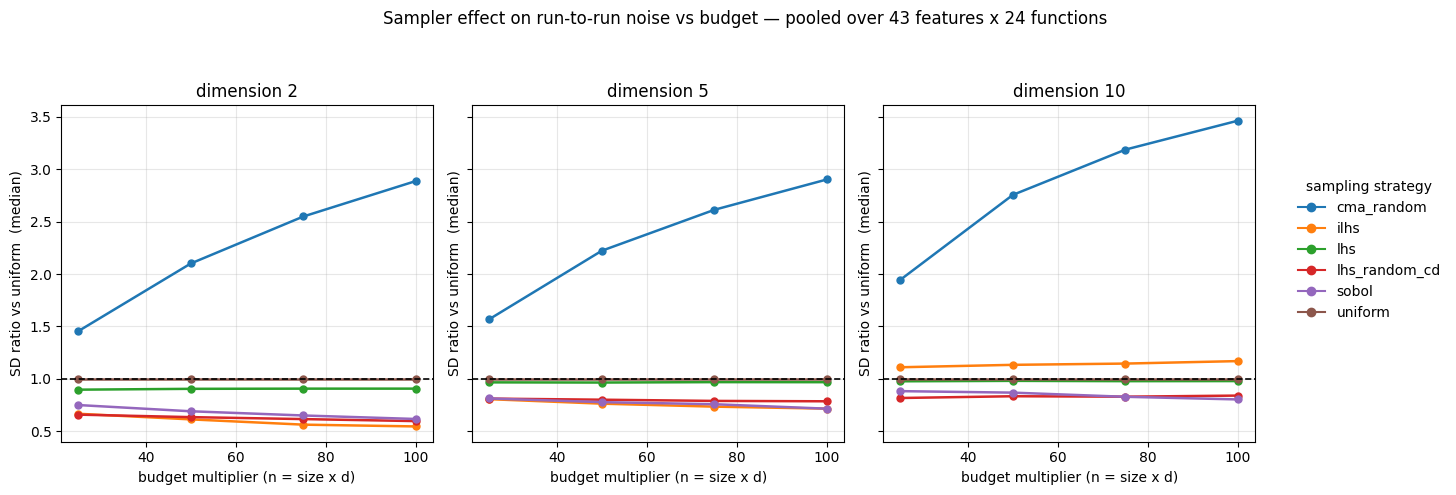

In [18]:
_ = rp.plot_ratio_vs_budget(tab["ratios"], show_band=False, logy=False, height_per=5)

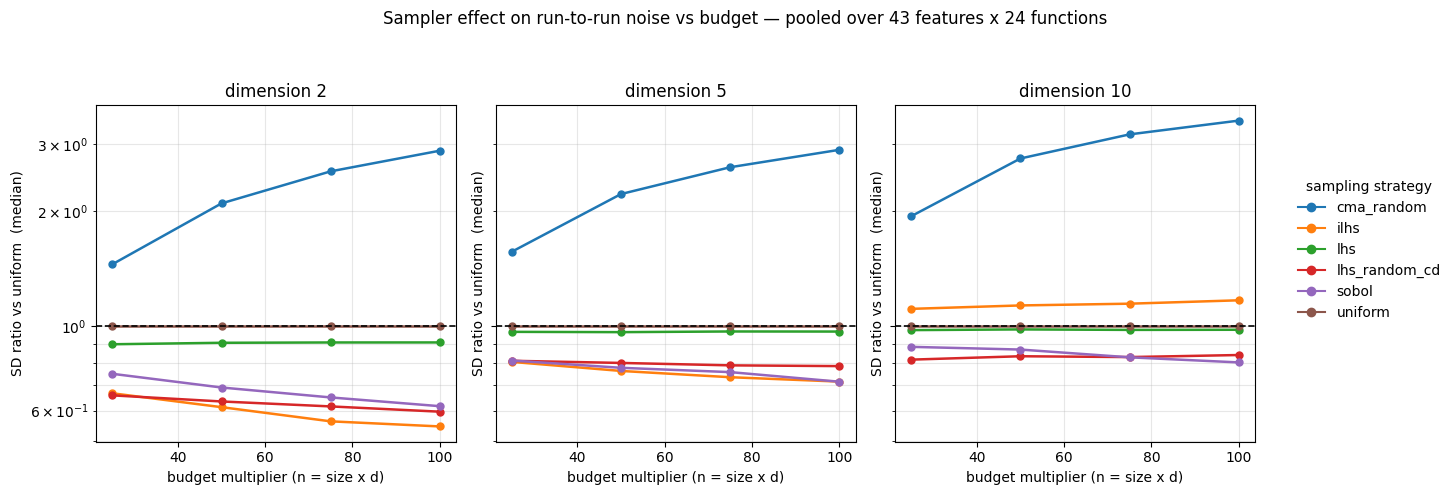

In [20]:
_ = rp.plot_ratio_vs_budget(tab["ratios"], show_band=False, height_per=5)
